c:\Data\Sequence_model\facs-openface-tools\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
Loading weights: 100%|██████████| 408/408 [00:00<00:00, 10607.50it/s]


Starting video processing...
Video info: 3275 frames, 30 fps, 2688x1520


Processing video: 100%|██████████| 3275/3275 [03:42<00:00, 14.72it/s]


Video processed successfully! Output saved to: output_with_emotions.mp4
Processed 1637 out of 3275 frames
Displaying output video:


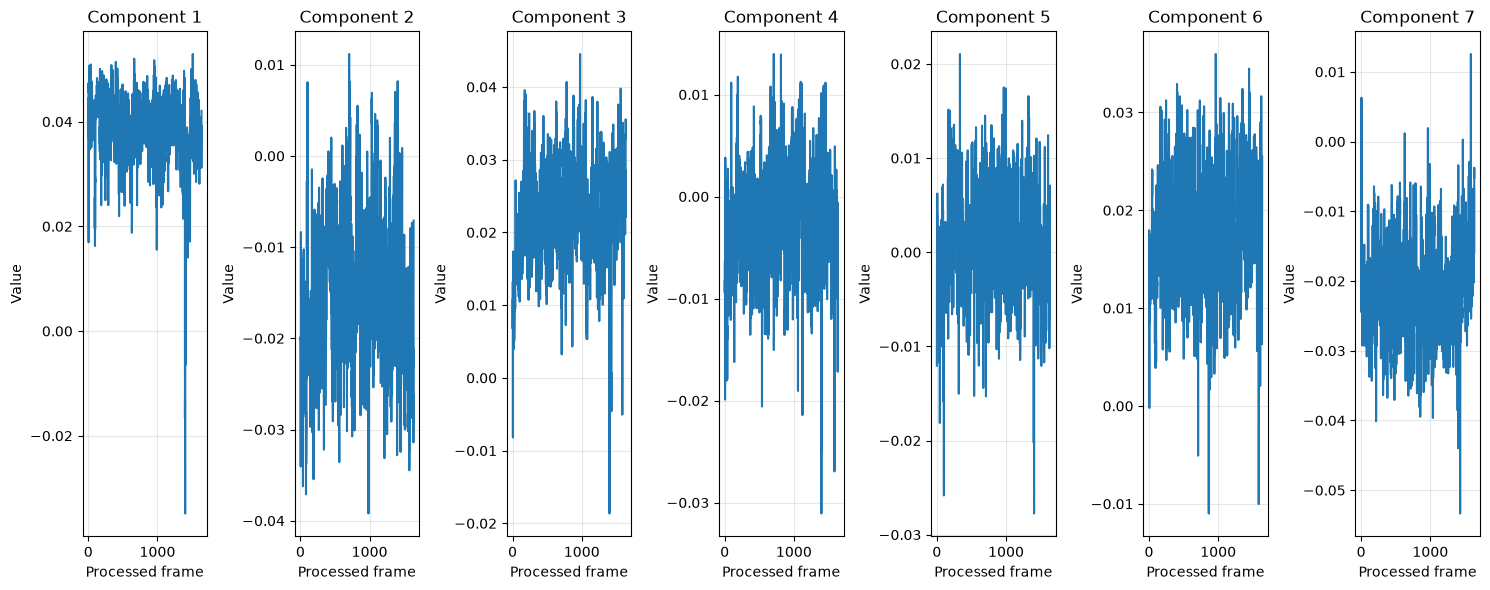

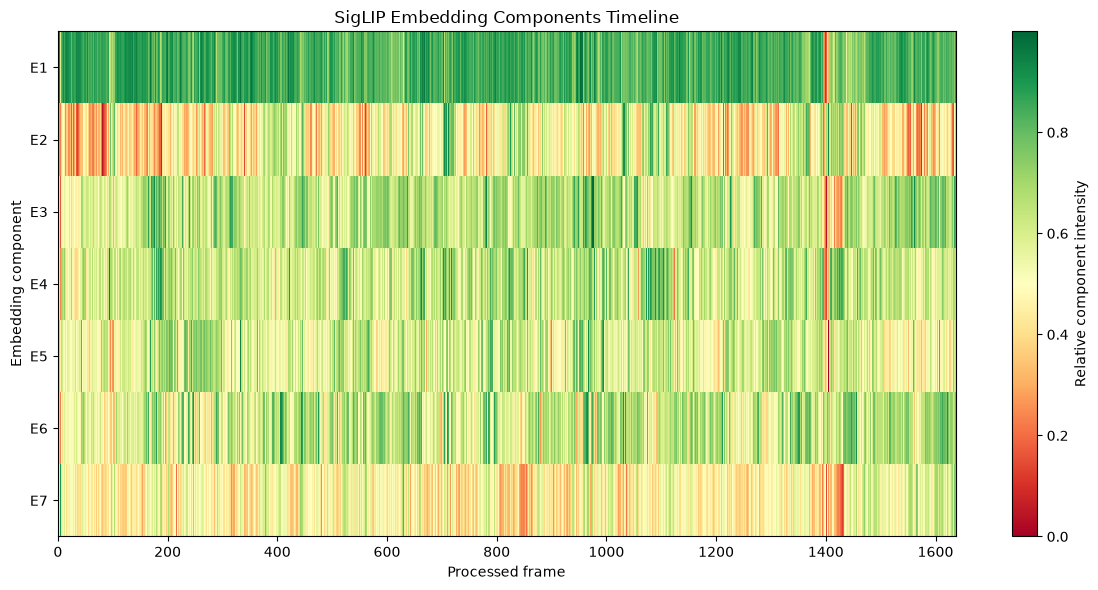

In [1]:
# %% [markdown]
# # Video Emotion Analysis with SigLIP
# This notebook processes a video frame by frame, extracts SigLIP embeddings, 
# and visualizes emotion changes on the output video.

# %%
import torch
import torch.nn.functional as F
from PIL import Image, ImageDraw, ImageFont
from transformers import AutoProcessor, AutoModel
import cv2
import numpy as np
from tqdm import tqdm
import os
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import Video, display
import urllib.request
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

# %%
# Configuration
class Config:
    model_name = "google/siglip-base-patch16-224"
    input_video = r"C:\Data\Sequence_model\facs-openface-tools\401033_S1 - Trim.mp4"
    output_video = "output_with_emotions.mp4"
    face_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    frame_skip = 2
    emotion_window = 10
    confidence_threshold = 0.5

# %%
# Initialize model
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Suppress transformer warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

processor = AutoProcessor.from_pretrained(Config.model_name)
model = AutoModel.from_pretrained(Config.model_name).to(device).eval()

# %%
# Initialize face detector with error handling
cascade_path = Config.face_cascade_path
if not os.path.exists(cascade_path):
    print("Downloading Haar cascade file...")
    url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
    urllib.request.urlretrieve(url, "haarcascade_frontalface_default.xml")
    cascade_path = "haarcascade_frontalface_default.xml"

face_cascade = cv2.CascadeClassifier(cascade_path)
if face_cascade.empty():
    raise ValueError("Failed to load cascade classifier!")

# %%
def detect_face(frame):
    """Detect the largest face in the frame."""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    
    if len(faces) == 0:
        return None
    
    # Get the largest face
    largest_face = max(faces, key=lambda x: x[2] * x[3])
    x, y, w, h = largest_face
    
    # Add some padding
    padding = int(0.2 * max(w, h))
    x = max(0, x - padding)
    y = max(0, y - padding)
    w = min(frame.shape[1] - x, w + 2 * padding)
    h = min(frame.shape[0] - y, h + 2 * padding)
    
    return x, y, w, h

# %%
def get_embedding(image, processor, model, device):
    """Extract a normalized SigLIP embedding from one image."""
    if image is None:
        return None

    try:
        inputs = processor(images=image, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(device)

        with torch.inference_mode():
            outputs = model.get_image_features(
                pixel_values=pixel_values
            )

            # Handle different Transformers versions
            if isinstance(outputs, torch.Tensor):
                embedding = outputs

            elif getattr(outputs, "image_embeds", None) is not None:
                embedding = outputs.image_embeds

            elif getattr(outputs, "pooler_output", None) is not None:
                embedding = outputs.pooler_output

            elif getattr(outputs, "last_hidden_state", None) is not None:
                # Mean-pool patch-token embeddings
                embedding = outputs.last_hidden_state.mean(dim=1)

            elif isinstance(outputs, (tuple, list)):
                embedding = outputs[0]
                if embedding.ndim == 3:
                    embedding = embedding.mean(dim=1)

            else:
                raise TypeError(
                    f"Unsupported SigLIP output type: {type(outputs)}"
                )

            embedding = F.normalize(embedding.float(), p=2, dim=-1)

        return embedding.squeeze(0).cpu().numpy()

    except Exception as e:
        print(
            f"Error processing image: {type(e).__name__}: {e}"
        )
        return None

# %%
def create_emotion_bars(embedding_history, width=300, height=100):
    """Create a visualization of emotion components from embedding history."""
    if len(embedding_history) == 0:
        return None
    
    # Create a simple visualization using PCA-like projection
    recent_embeddings = np.array(embedding_history[-Config.emotion_window:])
    if len(recent_embeddings) == 0:
        return None
    
    # Take mean of recent embeddings
    mean_embedding = np.mean(recent_embeddings, axis=0)
    
    # Use first 7 dimensions as emotion components
    emotion_components = mean_embedding[:7]
    
    # Normalize to [0, 1] for visualization
    emotion_components = (emotion_components - emotion_components.min()) / (emotion_components.max() - emotion_components.min() + 1e-8)
    
    # Create bar chart
    plt.figure(figsize=(width/100, height/100), dpi=100)
    colors = plt.cm.RdYlGn(emotion_components)
    
    bars = plt.bar(range(len(emotion_components)), emotion_components, color=colors)
    plt.ylim(0, 1.1)
    plt.xticks(range(len(emotion_components)), 
               ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7'], fontsize=8)
    plt.yticks([])
    plt.tight_layout(pad=0)
    
    # Convert to image
    plt.savefig('temp_emotion_bars.png', bbox_inches='tight', dpi=100, transparent=True)
    plt.close()
    
    # Load the image
    bars_img = cv2.imread('temp_emotion_bars.png', cv2.IMREAD_UNCHANGED)
    if os.path.exists('temp_emotion_bars.png'):
        os.remove('temp_emotion_bars.png')
    
    return bars_img

# %%
def process_video():
    """Main video processing function."""
    # Open video
    cap = cv2.VideoCapture(Config.input_video)
    if not cap.isOpened():
        print(f"Error: Could not open video {Config.input_video}")
        return None
    
    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Check if video is valid
    if total_frames <= 0:
        print("Error: Invalid video file")
        cap.release()
        return None
    
    print(f"Video info: {total_frames} frames, {fps} fps, {width}x{height}")
    
    # Setup video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(Config.output_video, fourcc, fps, (width, height))
    
    # Initialize variables
    frame_count = 0
    embedding_history = deque(maxlen=Config.emotion_window)
    processed_frames = 0
    emotion_values = []
    
    # Progress bar
    pbar = tqdm(total=total_frames, desc="Processing video")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        pbar.update(1)
        
        # Skip frames for speed
        if frame_count % Config.frame_skip != 0:
            out.write(frame)
            continue
        
        # Detect face
        face_region = detect_face(frame)
        embedding = None
        
        if face_region is not None:
            x, y, w, h = face_region
            face_img = frame[y:y+h, x:x+w]
            face_pil = Image.fromarray(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
            
            # Get embedding
            embedding = get_embedding(face_pil, processor, model, device)
        
        if embedding is not None:
            embedding_history.append(embedding)
            emotion_values.append(embedding[:7])
            
            # Draw face rectangle
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(frame, "Face Detected", (x, y-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            
            # Create emotion visualization
            emotion_bars = create_emotion_bars(list(embedding_history))
            if emotion_bars is not None:
                # Resize and position emotion bars
                bars_height = 100
                bars_width = 300
                emotion_bars_resized = cv2.resize(emotion_bars, (bars_width, bars_height))
                
                # Place in bottom-right corner
                h_offset = height - bars_height - 20
                w_offset = width - bars_width - 20
                
                # Make transparent overlay
                if emotion_bars_resized.shape[2] == 4:  # Has alpha channel
                    roi = frame[h_offset:h_offset+bars_height, w_offset:w_offset+bars_width]
                    alpha = emotion_bars_resized[:, :, 3] / 255.0
                    for c in range(3):
                        roi[:, :, c] = (1 - alpha) * roi[:, :, c] + alpha * emotion_bars_resized[:, :, c]
                    frame[h_offset:h_offset+bars_height, w_offset:w_offset+bars_width] = roi
                
                # Add label
                cv2.putText(frame, "Emotion Components", (w_offset, h_offset-5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        # Write frame
        out.write(frame)
        processed_frames += 1
    
    # Cleanup
    cap.release()
    out.release()
    pbar.close()
    
    print(f"\nVideo processed successfully! Output saved to: {Config.output_video}")
    print(f"Processed {processed_frames} out of {total_frames} frames")
    
    return emotion_values

# %%
# Main execution
print("Starting video processing...")

# Check if input video exists
if not os.path.exists(Config.input_video):
    print(f"Error: Input video not found at {Config.input_video}")
else:
    emotion_data = process_video()

# %%
# Display the output video
if os.path.exists(Config.output_video):
    print("Displaying output video:")
    display(Video(Config.output_video, width=640))
else:
    print("Output video not found. Processing may have failed.")

# %%
# Plot emotion changes over time
# Convert once, after processing
if (
    'emotion_data' in locals()
    and emotion_data is not None
    and len(emotion_data) > 0
):
    emotion_array = np.asarray(emotion_data)

    # Plot component changes
    plt.figure(figsize=(15, 6))

    for i in range(min(7, emotion_array.shape[1])):
        plt.subplot(1, 7, i + 1)
        plt.plot(emotion_array[:, i])
        plt.title(f"Component {i + 1}")
        plt.xlabel("Processed frame")
        plt.ylabel("Value")
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Timeline heatmap
    denominator = (
        emotion_array.max(axis=0)
        - emotion_array.min(axis=0)
        + 1e-8
    )

    emotion_normalized = (
        emotion_array - emotion_array.min(axis=0)
    ) / denominator

    plt.figure(figsize=(12, 6))
    plt.imshow(
        emotion_normalized.T,
        aspect="auto",
        cmap="RdYlGn",
        interpolation="nearest",
    )
    plt.colorbar(label="Relative component intensity")
    plt.xlabel("Processed frame")
    plt.ylabel("Embedding component")
    plt.title("SigLIP Embedding Components Timeline")

    component_count = min(7, emotion_array.shape[1])
    plt.yticks(
        range(component_count),
        [f"E{i + 1}" for i in range(component_count)],
    )

    plt.tight_layout()
    plt.show()
else:
    print("No valid embeddings were extracted.")

### quen vlm

In [ ]:
# %% [markdown]
# Video facial-behaviour analysis using Qwen2.5-VL
#
# The model analyses one sampled frame every few seconds and produces:
# - facial expression
# - gaze direction
# - head pose
# - visible behaviour
# - engagement
# - confidence
#
# Results are written to:
# 1. An annotated MP4
# 2. A CSV file

# %%
import ast
import json
import os
import re
from typing import Any, Dict, Optional

import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm import tqdm
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
)
from qwen_vl_utils import process_vision_info


# %%
class Config:
    model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

    input_video = (
        r"C:\Data\Sequence_model\facs-openface-tools\401033_S1 - Trim.mp4"
    )

    output_video = "qwen_behaviour_output.mp4"
    output_csv = "qwen_behaviour_results.csv"

    # Run Qwen every N seconds.
    # Do not run a 3B generative VLM on every video frame.
    analysis_interval_seconds = 0.3

    # Resize the image before sending it to Qwen.
    # This reduces memory use and inference time.
    max_image_width = 640

    # Maximum generated response length.
    max_new_tokens = 160

    # True: analyse the complete frame.
    # This is recommended for gaze and head orientation.
    use_full_frame = True

    # Optional face crop.
    face_padding_ratio = 0.8

    # Stop after this many seconds for a quick test.
    # Set to None for the complete video.
    test_duration_seconds = 60

    # If CUDA is unavailable, the script will use CPU.
    device = "cuda" if torch.cuda.is_available() else "cpu"


# %%
print(f"Using device: {Config.device}")
print(f"Loading model: {Config.model_name}")

if Config.device == "cuda":
    model_dtype = (
        torch.bfloat16
        if torch.cuda.is_bf16_supported()
        else torch.float16
    )
else:
    model_dtype = torch.float32


processor = AutoProcessor.from_pretrained(
    Config.model_name,
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    Config.model_name,
    torch_dtype=model_dtype,
    device_map="auto" if Config.device == "cuda" else None,
).eval()

if Config.device == "cpu":
    model = model.to("cpu")

print("Model loaded.")


# %%
# Haar cascade is optional. Full-frame analysis is preferred because
# gaze direction and head orientation require surrounding context.

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades
    + "haarcascade_frontalface_default.xml"
)

if face_cascade.empty():
    raise RuntimeError("Could not initialise Haar face detector.")


# %%
def detect_largest_face(
    frame: np.ndarray,
) -> Optional[tuple[int, int, int, int]]:
    """
    Detect the largest frontal face.

    Note:
        Haar cascades can fail when the person looks sideways.
        Therefore, full-frame analysis is usually better for gaze.
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(50, 50),
    )

    if len(faces) == 0:
        return None

    x, y, w, h = max(
        faces,
        key=lambda box: box[2] * box[3],
    )

    return int(x), int(y), int(w), int(h)


# %%
def crop_face_with_context(
    frame: np.ndarray,
    face_box: tuple[int, int, int, int],
    padding_ratio: float = 0.8,
) -> np.ndarray:
    """
    Crop a face with substantial surrounding context.

    The extra context helps preserve:
    - head orientation
    - shoulders
    - gaze direction
    - interaction posture
    """
    x, y, w, h = face_box

    padding_x = int(w * padding_ratio)
    padding_y = int(h * padding_ratio)

    x1 = max(0, x - padding_x)
    y1 = max(0, y - padding_y)
    x2 = min(frame.shape[1], x + w + padding_x)
    y2 = min(frame.shape[0], y + h + padding_y)

    return frame[y1:y2, x1:x2]


# %%
def resize_for_model(
    frame: np.ndarray,
    max_width: int,
) -> np.ndarray:
    """Resize while maintaining the original aspect ratio."""
    height, width = frame.shape[:2]

    if width <= max_width:
        return frame

    scale = max_width / width
    new_height = max(1, int(height * scale))

    return cv2.resize(
        frame,
        (max_width, new_height),
        interpolation=cv2.INTER_AREA,
    )


# %%
def default_result() -> Dict[str, Any]:
    return {
        "face_visible": False,
        "expression": "unclear",
        "gaze": "unclear",
        "head_pose": "unclear",
        "eyes": "unclear",
        "mouth": "unclear",
        "engagement": "unclear",
        "behaviour": "unclear",
        "confidence": 0.0,
    }


# %%
BEHAVIOUR_PROMPT = """
Analyse only directly visible behaviour in this image.

Focus on the most prominent person, especially:
- facial expression
- whether the person is smiling, neutral, frowning, tense, or unclear
- gaze direction
- whether the person looks toward the camera, left, right, up, down,
  or away
- head orientation
- whether the head is frontal, turned left, turned right, tilted,
  lowered, or raised
- eye state
- mouth state
- visible engagement or withdrawal

Do not diagnose emotions, mental states, personality, or medical
conditions. Do not infer anything that is not visually observable.

Return exactly one JSON object using this schema:

{
  "face_visible": true,
  "expression": "neutral",
  "gaze": "looking away",
  "head_pose": "turned left",
  "eyes": "open",
  "mouth": "closed",
  "engagement": "unclear",
  "behaviour": "brief factual description",
  "confidence": 0.75
}

Allowed expression values:
"smiling", "slight smile", "neutral", "frowning", "tense",
"surprised", "unclear"

Allowed gaze values:
"toward camera", "left", "right", "up", "down", "looking away",
"eyes closed", "unclear"

Allowed head_pose values:
"frontal", "turned left", "turned right", "tilted left",
"tilted right", "lowered", "raised", "unclear"

Allowed engagement values:
"attentive", "withdrawn", "active", "unclear"

Return JSON only. Do not add Markdown or commentary.
""".strip()


# %%
def extract_json_object(text: str) -> Optional[Dict[str, Any]]:
    """
    Extract JSON robustly, even if the model adds a code block.
    """
    if not text:
        return None

    cleaned = text.strip()

    cleaned = re.sub(
        r"^```(?:json)?\s*",
        "",
        cleaned,
        flags=re.IGNORECASE,
    )
    cleaned = re.sub(r"\s*```$", "", cleaned)

    first_brace = cleaned.find("{")
    last_brace = cleaned.rfind("}")

    if first_brace == -1 or last_brace == -1:
        return None

    candidate = cleaned[first_brace:last_brace + 1]

    try:
        parsed = json.loads(candidate)
        if isinstance(parsed, dict):
            return parsed
    except json.JSONDecodeError:
        pass

    # Fallback for occasional single-quoted Python dictionaries.
    try:
        parsed = ast.literal_eval(candidate)
        if isinstance(parsed, dict):
            return parsed
    except (ValueError, SyntaxError):
        pass

    return None


# %%
def normalise_result(
    parsed: Optional[Dict[str, Any]],
) -> Dict[str, Any]:
    """Validate and normalise the generated dictionary."""
    result = default_result()

    if not parsed:
        return result

    for key in result:
        if key in parsed:
            result[key] = parsed[key]

    face_visible = result["face_visible"]

    if isinstance(face_visible, str):
        face_visible = face_visible.strip().lower() == "true"

    result["face_visible"] = bool(face_visible)

    try:
        confidence = float(result["confidence"])
    except (TypeError, ValueError):
        confidence = 0.0

    result["confidence"] = float(
        np.clip(confidence, 0.0, 1.0)
    )

    for key in (
        "expression",
        "gaze",
        "head_pose",
        "eyes",
        "mouth",
        "engagement",
        "behaviour",
    ):
        result[key] = str(result[key]).strip()

    return result


# %%
def analyse_frame_with_qwen(
    frame_bgr: np.ndarray,
) -> Dict[str, Any]:
    """
    Analyse one frame using Qwen2.5-VL.
    """
    if frame_bgr is None or frame_bgr.size == 0:
        return default_result()

    prepared_frame = resize_for_model(
        frame_bgr,
        Config.max_image_width,
    )

    frame_rgb = cv2.cvtColor(
        prepared_frame,
        cv2.COLOR_BGR2RGB,
    )
    pil_image = Image.fromarray(frame_rgb)

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": pil_image,
                },
                {
                    "type": "text",
                    "text": BEHAVIOUR_PROMPT,
                },
            ],
        }
    ]

    try:
        chat_text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        image_inputs, video_inputs = process_vision_info(
            messages
        )

        inputs = processor(
            text=[chat_text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )

        # device_map="auto" may place the model on a selected GPU.
        model_device = next(model.parameters()).device
        inputs = {
            key: value.to(model_device)
            if isinstance(value, torch.Tensor)
            else value
            for key, value in inputs.items()
        }

        with torch.inference_mode():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=Config.max_new_tokens,
                do_sample=False,
            )

        # Remove input prompt tokens from generated output.
        generated_trimmed = [
            output_ids[len(input_ids):]
            for input_ids, output_ids in zip(
                inputs["input_ids"],
                generated_ids,
            )
        ]

        response = processor.batch_decode(
            generated_trimmed,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]

        parsed = extract_json_object(response)

        if parsed is None:
            print(
                "Could not parse Qwen response:",
                response,
            )

        return normalise_result(parsed)

    except torch.cuda.OutOfMemoryError:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print("CUDA out of memory during frame analysis.")
        return default_result()

    except Exception as exc:
        print(
            "Qwen frame-analysis error: "
            f"{type(exc).__name__}: {exc}"
        )
        return default_result()


# %%
def wrap_text(
    text: str,
    max_characters: int = 55,
) -> list[str]:
    """Simple line wrapping for OpenCV overlays."""
    words = str(text).split()

    if not words:
        return [""]

    lines: list[str] = []
    current_line = words[0]

    for word in words[1:]:
        candidate = f"{current_line} {word}"

        if len(candidate) <= max_characters:
            current_line = candidate
        else:
            lines.append(current_line)
            current_line = word

    lines.append(current_line)
    return lines


# %%
def draw_behaviour_overlay(
    frame: np.ndarray,
    result: Dict[str, Any],
    timestamp_seconds: float,
    last_analysis_time: float,
) -> np.ndarray:
    """Draw Qwen output on a video frame."""
    output = frame.copy()

    timestamp = (
        f"{int(timestamp_seconds // 60):02d}:"
        f"{int(timestamp_seconds % 60):02d}"
    )

    age = max(
        0.0,
        timestamp_seconds - last_analysis_time,
    )

    lines = [
        f"Time: {timestamp}",
        f"Expression: {result['expression']}",
        f"Gaze: {result['gaze']}",
        f"Head: {result['head_pose']}",
        f"Eyes: {result['eyes']}",
        f"Mouth: {result['mouth']}",
        f"Engagement: {result['engagement']}",
        f"Confidence: {result['confidence']:.2f}",
        f"Last analysis: {age:.1f}s ago",
    ]

    behaviour_lines = wrap_text(
        f"Behaviour: {result['behaviour']}",
        max_characters=50,
    )
    lines.extend(behaviour_lines)

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.55
    thickness = 1
    line_height = 24
    padding = 12

    box_width = min(620, output.shape[1] - 20)
    box_height = (
        len(lines) * line_height
        + 2 * padding
    )

    overlay = output.copy()

    cv2.rectangle(
        overlay,
        (10, 10),
        (10 + box_width, 10 + box_height),
        (0, 0, 0),
        -1,
    )

    output = cv2.addWeighted(
        overlay,
        0.70,
        output,
        0.30,
        0,
    )

    y = 10 + padding + 16

    for line in lines:
        cv2.putText(
            output,
            line,
            (10 + padding, y),
            font,
            font_scale,
            (255, 255, 255),
            thickness,
            cv2.LINE_AA,
        )
        y += line_height

    return output


# %%
def process_video() -> pd.DataFrame:
    input_path = Config.input_video

    if not os.path.exists(input_path):
        raise FileNotFoundError(
            f"Video does not exist: {input_path}"
        )

    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open video: {input_path}"
        )

    fps = float(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    reported_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if fps <= 0:
        fps = 25.0

    analysis_every_frames = max(
        1,
        round(
            fps
            * Config.analysis_interval_seconds
        ),
    )

    if Config.test_duration_seconds is not None:
        maximum_frames = min(
            reported_frames,
            round(
                fps
                * Config.test_duration_seconds
            ),
        )
    else:
        maximum_frames = reported_frames

    print(
        f"Video: {width}x{height}, "
        f"{fps:.3f} FPS, "
        f"{reported_frames:,} reported frames"
    )
    print(
        "Qwen analysis interval: "
        f"{Config.analysis_interval_seconds:.1f} seconds "
        f"({analysis_every_frames} frames)"
    )

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")

    writer = cv2.VideoWriter(
        Config.output_video,
        fourcc,
        fps,
        (width, height),
    )

    if not writer.isOpened():
        cap.release()
        raise RuntimeError(
            f"Could not create {Config.output_video}"
        )

    results: list[Dict[str, Any]] = []

    current_result = default_result()
    frame_index = 0
    last_analysis_time = 0.0
    decode_failed_early = False

    progress_total = (
        maximum_frames
        if maximum_frames > 0
        else None
    )

    progress = tqdm(
        total=progress_total,
        desc="Processing video",
    )

    while True:
        if (
            maximum_frames > 0
            and frame_index >= maximum_frames
        ):
            break

        success, frame = cap.read()

        if not success:
            if (
                reported_frames > 0
                and frame_index
                < min(
                    reported_frames,
                    maximum_frames,
                ) - 1
            ):
                decode_failed_early = True
                print(
                    "\nVideo decoding stopped early at "
                    f"frame {frame_index:,}."
                )
            break

        timestamp_seconds = frame_index / fps

        should_analyse = (
            frame_index == 0
            or frame_index % analysis_every_frames == 0
        )

        if should_analyse:
            analysis_frame = frame

            face_box = detect_largest_face(frame)

            if (
                not Config.use_full_frame
                and face_box is not None
            ):
                analysis_frame = crop_face_with_context(
                    frame,
                    face_box,
                    Config.face_padding_ratio,
                )

            current_result = analyse_frame_with_qwen(
                analysis_frame
            )
            last_analysis_time = timestamp_seconds

            record = {
                "frame_index": frame_index,
                "timestamp_seconds": round(
                    timestamp_seconds,
                    3,
                ),
                **current_result,
            }
            results.append(record)

            print(
                f"\n[{timestamp_seconds:8.2f}s] "
                f"expression={current_result['expression']}, "
                f"gaze={current_result['gaze']}, "
                f"head={current_result['head_pose']}, "
                f"behaviour={current_result['behaviour']}"
            )

        annotated = draw_behaviour_overlay(
            frame,
            current_result,
            timestamp_seconds,
            last_analysis_time,
        )

        writer.write(annotated)

        frame_index += 1
        progress.update(1)

    progress.close()
    cap.release()
    writer.release()

    result_df = pd.DataFrame(results)
    result_df.to_csv(
        Config.output_csv,
        index=False,
    )

    print()
    print(f"Frames read: {frame_index:,}")
    print(f"Qwen analyses: {len(results):,}")
    print(f"Annotated video: {Config.output_video}")
    print(f"CSV results: {Config.output_csv}")

    if decode_failed_early:
        print(
            "Warning: source video decoding ended early. "
            "The source may be truncated."
        )

    return result_df


# %%
behaviour_df = process_video()

behaviour_df.head(20)

Using device: cuda
Loading model: Qwen/Qwen2.5-VL-3B-Instruct


Loading weights: 100%|██████████| 824/824 [00:02<00:00, 291.82it/s]


Model loaded.
Video: 2688x1520, 30.005 FPS, 3,275 reported frames
Qwen analysis interval: 5.0 seconds (150 frames)


Processing video:   0%|          | 4/1800 [00:03<21:20,  1.40it/s]  


[    0.00s] expression=neutral, gaze=looking away, head=turned left, behaviour=sitting and looking to the side


...

Processing video:  92%|█████████▏| 1657/1800 [01:23<00:22,  6.29it/s]


[   54.99s] expression=neutral, gaze=looking away, head=turned left, behaviour=gesturing with both hands while sitting


Processing video: 100%|██████████| 1800/1800 [01:28<00:00, 20.43it/s]


Frames read: 1,800
Qwen analyses: 12
Annotated video: qwen_behaviour_output.mp4
CSV results: qwen_behaviour_results.csv


,frame_index,timestamp_seconds,face_visible,expression,gaze,head_pose,eyes,mouth,engagement,behaviour,confidence
0,0,0.000,True,neutral,looking away,turned left,open,closed,unclear,sitting and looking to the side,0.75
1,150,4.999,True,neutral,looking away,turned left,open,closed,unclear,sitting and looking to the side,0.75
2,300,9.998,True,neutral,looking away,turned left,open,closed,unclear,sitting and looking to the side,0.75
3,450,14.997,True,neutral,looking away,turned left,open,closed,unclear,sitting and holding hands together,0.75
4,600,19.996,True,neutral,looking away,turned left,open,closed,unclear,sitting and gesturing with hands,0.75
5,750,24.995,True,neutral,looking away,turned left,open,closed,unclear,"sitting with hands clasped, looking to the side",0.75
6,900,29.995,True,neutral,looking away,turned left,open,closed,unclear,sitting with hands clasped and looking to the ...,0.75
7,1050,34.994,True,neutral,looking away,turned left,open,closed,unclear,sitting with hands clasped and looking to the ...,0.75
8,1200,39.993,True,neutral,looking away,turned left,open,closed,unclear,sitting with hands clasped and looking to the ...,0.75
9,1350,44.992,True,neutral,looking away,turned left,open,closed,unclear,sitting and gesturing with hands,0.75


In [3]:
import sys

print(sys.executable)

c:\Data\Sequence_model\facs-openface-tools\.venv\Scripts\python.exe


In [ ]:
# %%
import os
import cv2
import torch
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from collections import deque
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

# %%
class Config:
    model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

    input_video = r"C:/Data/Sequence_model/facs-openface-tools/401033_S1 - Trim.mp4"
    output_video = "qwen_fixed_output.mp4"
    output_csv = "qwen_fixed_results.csv"

    # 🔥 FIX 1: much higher temporal resolution
    analysis_interval_seconds = 0.5

    # 🔥 FIX 2: use face crop with context
    use_full_frame = False
    face_padding_ratio = 1.2

    # 🔥 FIX 3: multi-frame context
    temporal_window = 5   # frames

    max_image_width = 640
    max_new_tokens = 120

    device = "cuda" if torch.cuda.is_available() else "cpu"


# %%
print("Loading model...")

processor = AutoProcessor.from_pretrained(Config.model_name)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    Config.model_name,
    torch_dtype=torch.float16 if Config.device == "cuda" else torch.float32,
).eval().to(Config.device)

print("Model loaded")


# %%
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)


def detect_face(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    if len(faces) == 0:
        return None

    return max(faces, key=lambda f: f[2] * f[3])


def crop_face(frame, box):
    x, y, w, h = box
    pad = int(max(w, h) * Config.face_padding_ratio)

    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(frame.shape[1], x + w + pad)
    y2 = min(frame.shape[0], y + h + pad)

    return frame[y1:y2, x1:x2]


# %%
# 🔥 FIXED PROMPT
PROMPT =  """
You are analysing a short video clip of a person in a conversation.

Your task is to describe ONLY visible behaviour.

Focus on:
- whether the person is speaking
- where the person is looking
- head movement or direction
- facial expression
- engagement level

STRICT RULES:
- Always give an answer (do NOT return "unclear" unless face is not visible)
- If the mouth is slightly open or changing → mark as "speaking"
- If eyes are not facing camera → estimate direction (left/right/up/down)
- If head is tilted or turned → describe it
- If expression is subtle → still choose the closest option

OUTPUT FORMAT (must follow exactly):

{
 "speaking": "yes/no",
 "gaze": "left/right/up/down/forward",
 "head": "still/left/right/up/down/moving",
 "expression": "neutral/smile/tense/thinking",
 "engagement": "engaged/neutral/withdrawn",
 "behaviour": "short sentence describing behaviour",
 "confidence": 0.0
}

EXAMPLES:

{
 "speaking": "yes",
 "gaze": "left",
 "head": "moving",
 "expression": "thinking",
 "engagement": "engaged",
 "behaviour": "speaking while looking left and moving head slightly",
 "confidence": 0.8
}

{
 "speaking": "no",
 "gaze": "down",
 "head": "still",
 "expression": "tense",
 "engagement": "withdrawn",
 "behaviour": "looking down quietly with tense expression",
 "confidence": 0.7
}
"""


# %%
def analyse_clip(frames):
    pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)) for f in frames]

    messages = [{
        "role": "user",
        "content": [
            {"type": "video", "video": pil_frames},
            {"type": "text", "text": PROMPT}
        ]
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        return_tensors="pt"
    ).to(Config.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=Config.max_new_tokens)

    output = processor.batch_decode(output_ids, skip_special_tokens=True)[0]

    # simple JSON extraction
    try:
        start = output.find("{")
        end = output.rfind("}") + 1
        return eval(output[start:end])
    except:
        return {"expression": "unclear", "mouth": "unclear", "confidence": 0}


# %%
def process_video():
    cap = cv2.VideoCapture(Config.input_video)

    fps = cap.get(cv2.CAP_PROP_FPS)
    interval = int(fps * Config.analysis_interval_seconds)

    width = int(cap.get(3))
    height = int(cap.get(4))

    out = cv2.VideoWriter(
        Config.output_video,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    buffer = deque(maxlen=Config.temporal_window)

    frame_idx = 0
    results = []
    current_result = {}

    pbar = tqdm(total=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        buffer.append(frame)

        if frame_idx % interval == 0 and len(buffer) == Config.temporal_window:

            # face crop
            if not Config.use_full_frame:
                box = detect_face(frame)
                if box is not None:
                    buffer_crop = [crop_face(f, box) for f in buffer]
                else:
                    buffer_crop = list(buffer)
            else:
                buffer_crop = list(buffer)

            current_result = analyse_clip(buffer_crop)

            results.append({
                "frame": frame_idx,
                "time": frame_idx / fps,
                **current_result
            })

        # overlay
        y = 30
        for k, v in current_result.items():
            cv2.putText(frame, f"{k}: {v}", (10, y),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
            y += 20

        out.write(frame)

        frame_idx += 1
        pbar.update(1)

    cap.release()
    out.release()
    pbar.close()

    df = pd.DataFrame(results)
    df.to_csv(Config.output_csv, index=False)

    print("Done")
    return df


# %%
df = process_video()
df.head()

Loading model...


Loading weights: 100%|██████████| 824/824 [00:01<00:00, 512.55it/s]


Model loaded


100%|██████████| 3275/3275 [08:58<00:00,  6.08it/s]

Done


,frame,time,expression,mouth,confidence
0,15,0.49991,unclear,unclear,0
1,30,0.99982,unclear,unclear,0
2,45,1.49973,unclear,unclear,0
3,60,1.99964,unclear,unclear,0
4,75,2.49955,unclear,unclear,0


In [4]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from collections import deque
import json
import re

from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from qwen_vl_utils import process_vision_info


# ================= CONFIG =================
class Config:
    model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

    input_video = "C:/Data/Sequence_model/facs-openface-tools/401033_S1 - Trim.mp4"
    output_video = "qwen_final_output.mp4"
    output_csv = "qwen_final_results.csv"

    analysis_interval_seconds = 0.5
    temporal_window = 5

    max_new_tokens = 120
    device = "cuda" if torch.cuda.is_available() else "cpu"


# ================= MODEL =================
print("Loading model...")

processor = AutoProcessor.from_pretrained(Config.model_name)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    Config.model_name,
    torch_dtype=torch.float16 if Config.device == "cuda" else torch.float32,
).eval().to(Config.device)

print("Model loaded")


# ================= PROMPT =================
PROMPT = """
Analyse the visible behaviour of the person in this short video.

Focus ONLY on observable behaviour:

- speaking (yes or no)
- gaze direction (left, right, forward, up, down)
- head movement (still, moving, left, right, up, down)
- facial expression (neutral, smile, thinking, tense)
- engagement (engaged, neutral, withdrawn)

Rules:
- ALWAYS give an answer
- If mouth is slightly open or changing → speaking = yes
- Estimate gaze direction even if unsure
- Do NOT output "unclear"

Return ONLY JSON:

{
 "speaking": "yes/no",
 "gaze": "...",
 "head": "...",
 "expression": "...",
 "engagement": "...",
 "behaviour": "...",
 "confidence": 0.0
}
"""


# ================= JSON PARSER =================
def parse_json(text):
    try:
        text = re.sub(r"```.*?```", "", text, flags=re.S)
        start = text.find("{")
        end = text.rfind("}") + 1
        return json.loads(text[start:end])
    except:
        return None


# ================= QWEN INFERENCE =================
def analyse_clip(frames):
    pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)) for f in frames]

    messages = [{
        "role": "user",
        "content": [
            {"type": "video", "video": pil_frames},
            {"type": "text", "text": PROMPT}
        ]
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        return_tensors="pt"
    ).to(Config.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=Config.max_new_tokens)

    output = processor.batch_decode(output_ids, skip_special_tokens=True)[0]

    parsed = parse_json(output)

    if parsed is None:
        return {
            "speaking": "no",
            "gaze": "forward",
            "head": "still",
            "expression": "neutral",
            "engagement": "neutral",
            "behaviour": "no clear behaviour",
            "confidence": 0.3
        }

    return parsed


# ================= UI OVERLAY =================
def draw_overlay(frame, result):
    overlay = frame.copy()

    # Big dark panel
    cv2.rectangle(overlay, (20, 20), (650, 260), (0, 0, 0), -1)
    frame = cv2.addWeighted(overlay, 0.7, frame, 0.3, 0)

    y = 60

    def put(text, size=0.8):
        nonlocal y
        cv2.putText(
            frame,
            text,
            (40, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            size,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )
        y += 40

    put(f"Speaking: {result.get('speaking','')}", 1.0)
    put(f"Gaze: {result.get('gaze','')}")
    put(f"Head: {result.get('head','')}")
    put(f"Expression: {result.get('expression','')}")
    put(f"Engagement: {result.get('engagement','')}")

    behaviour = result.get("behaviour", "")
    put(f"Behaviour: {behaviour}", 0.7)

    put(f"Confidence: {result.get('confidence',0):.2f}", 0.6)

    return frame


# ================= MAIN =================
def process_video():
    cap = cv2.VideoCapture(Config.input_video)

    fps = cap.get(cv2.CAP_PROP_FPS)
    interval = int(fps * Config.analysis_interval_seconds)

    width = int(cap.get(3))
    height = int(cap.get(4))

    out = cv2.VideoWriter(
        Config.output_video,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    buffer = deque(maxlen=Config.temporal_window)

    frame_idx = 0
    results = []
    current_result = {}

    pbar = tqdm(total=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        buffer.append(frame)

        if frame_idx % interval == 0 and len(buffer) == Config.temporal_window:
            current_result = analyse_clip(list(buffer))

            results.append({
                "frame": frame_idx,
                "time": frame_idx / fps,
                **current_result
            })

        frame = draw_overlay(frame, current_result)
        out.write(frame)

        frame_idx += 1
        pbar.update(1)

    cap.release()
    out.release()
    pbar.close()

    df = pd.DataFrame(results)
    df.to_csv(Config.output_csv, index=False)

    print("Done")
    return df


# ================= RUN =================
df = process_video()
print(df.head())

Loading model...


Loading weights: 100%|██████████| 824/824 [00:00<00:00, 1427.44it/s]


Model loaded


 14%|█▎        | 450/3275 [01:30<05:37,  8.37it/s]

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1


 14%|█▎        | 450/3275 [01:40<05:37,  8.37it/s]

## video lama

In [5]:
import sys
import subprocess

packages = [
    "transformers",
    "accelerate",
    "safetensors",
    "opencv-python",
    "pandas",
    "pillow",
    "tqdm",
    "av",
]

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-U",
    *packages,
])

print("Installation complete.")
print("Restart the notebook kernel before continuing.")

Installation complete.
Restart the notebook kernel before continuing.


In [1]:
import ast
import gc
import json
import os
import re
import shutil
import subprocess
import tempfile
from pathlib import Path
from typing import Any, Dict, Optional

import cv2
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoProcessor

c:\Data\Sequence_model\facs-openface-tools\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import ast
import gc
import json
import os
import re
import shutil
import subprocess
import tempfile
from pathlib import Path
from typing import Any, Dict, Optional

import cv2
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoProcessor

In [3]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

    free_bytes, total_bytes = torch.cuda.mem_get_info()

    print(f"Free VRAM:  {free_bytes / 1024**3:.2f} GB")
    print(f"Total VRAM: {total_bytes / 1024**3:.2f} GB")
else:
    raise RuntimeError(
        "CUDA is not available. VideoLLaMA3-7B is not practical on CPU."
    )

PyTorch: 2.13.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5090
Free VRAM:  30.20 GB
Total VRAM: 31.84 GB


In [ ]:
# ================== COMPLETE VIDEOLLAMA3 PIPELINE ==================

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import cv2
import torch
import json
import re
import gc
import subprocess
from pathlib import Path
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoProcessor

# ================== CONFIG ==================
class Config:
    model_name = "DAMO-NLP-SG/VideoLLaMA3-7B"

    input_video = r"C:\Data\Sequence_model\facs-openface-tools\401033_S1 - Trim.mp4"
    temp_dir = "temp_clips"

    output_csv = "videollama_results.csv"

    # SAFE SETTINGS (no crash)
    clip_duration = 2.0
    stride = 1.0
    fps = 2
    max_frames = 8

    max_new_tokens = 150

# ================== SETUP ==================
Path(Config.temp_dir).mkdir(exist_ok=True)

print("Loading model...")

processor = AutoProcessor.from_pretrained(
    Config.model_name,
    trust_remote_code=True
)

# 1. Use flash attention if you can install it (pip install flash-attn --no-build-isolation)
model = AutoModelForCausalLM.from_pretrained(
    Config.model_name,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,          # matches official example, better numerics on A100-class GPUs
    device_map={"": 0},
    attn_implementation="flash_attention_2",  # or "sdpa" if flash-attn won't build
).eval()

print("Model loaded")

# ================== PROMPT ==================
PROMPT = """
Analyse behaviour of the main person in the video.

Focus only on visible behaviour:

- speaking or not
- gaze direction
- head movement
- facial expression
- body/hand movement

Rules:
- Always give concrete answers
- No placeholders
- Use video motion

Return JSON:

{
 "speaking": "yes" or "no",
 "gaze": "left/right/forward/up/down",
 "head": "still/moving",
 "expression": "neutral/smile/thinking/tense",
 "body": "still/gesturing/clasped/leaning",
 "behaviour": "short description",
 "confidence": 0.0
}
"""

# ================== JSON PARSER ==================
def parse_json(text):
    try:
        text = re.sub(r"```.*?```", "", text, flags=re.S)
        start = text.find("{")
        end = text.rfind("}") + 1
        return json.loads(text[start:end])
    except:
        return None

# ================== CLIP EXTRACTION ==================
def extract_clip(start, duration, idx, max_side=448):
    out = f"{Config.temp_dir}/clip_{idx}.mp4"
    cmd = [
        "ffmpeg", "-y",
        "-ss", str(start),
        "-i", Config.input_video,
        "-t", str(duration),
        "-an",
        "-vf", f"scale='if(gt(iw,ih),{max_side},-2)':'if(gt(iw,ih),-2,{max_side})'",
        "-c:v", "libx264",
        "-preset", "veryfast",
        out
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return out

# ================== MODEL INFERENCE ==================
def analyse_clip(path):
    conversation = [{
        "role": "user",
        "content": [
            {
                "type": "video",
                "video": {
                    "video_path": path,
                    "fps": Config.fps,
                    "max_frames": Config.max_frames
                }
            },
            {"type": "text", "text": PROMPT}
        ]
    }]

    try:
        inputs = processor(conversation=conversation, return_tensors="pt")

        for k in inputs:
            if isinstance(inputs[k], torch.Tensor):
                inputs[k] = inputs[k].to(0)
                if k == "pixel_values":
                    inputs[k] = inputs[k].to(torch.float16)

        with torch.inference_mode():
            out_ids = model.generate(
                **inputs,
                max_new_tokens=Config.max_new_tokens,
                do_sample=False
            )

        output = processor.batch_decode(out_ids, skip_special_tokens=True)[0]

        print("\nRAW:", output[:200])

        parsed = parse_json(output)

        if parsed is None:
            return {
                "speaking": "no",
                "gaze": "forward",
                "head": "still",
                "expression": "neutral",
                "body": "still",
                "behaviour": "fallback",
                "confidence": 0.3
            }

        return parsed

    except Exception as e:
        print("ERROR:", e)
        torch.cuda.empty_cache()
        return {
            "speaking": "no",
            "gaze": "forward",
            "head": "still",
            "expression": "neutral",
            "body": "still",
            "behaviour": "error fallback",
            "confidence": 0.2
        }

    finally:
        gc.collect()
        torch.cuda.empty_cache()

# ================== VIDEO META ==================
cap = cv2.VideoCapture(Config.input_video)
fps = cap.get(cv2.CAP_PROP_FPS)
frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
duration = frames / fps
cap.release()

print(f"Video duration: {duration:.2f}s")

# ================== MAIN LOOP ==================
results = []

t = 0
idx = 0

while t < min(duration, 30):   # first 30s test
    clip = extract_clip(t, Config.clip_duration, idx)

    res = analyse_clip(clip)

    results.append({
        "start": t,
        "end": t + Config.clip_duration,
        **res
    })

    print(f"\n{t:.1f}s → {res['behaviour']}")

    os.remove(clip)

    t += Config.stride
    idx += 1

# ================== SAVE ==================
import pandas as pd
df = pd.DataFrame(results)
df.to_csv(Config.output_csv, index=False)

print("\nSaved:", Config.output_csv)
df.head()

c:\Data\Sequence_model\facs-openface-tools\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model...


Loading checkpoint shards: 100%|██████████| 4/4 [02:27<00:00, 36.76s/it]


Model loaded
Video duration: 109.15s
ERROR: CUDA out of memory. Tried to allocate 127.00 GiB. GPU 0 has a total capacity of 31.84 GiB of which 10.09 GiB is free. Of the allocated memory 19.82 GiB is allocated by PyTorch, and 186.86 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

0.0s → error fallback
ERROR: CUDA out of memory. Tried to allocate 115.33 GiB. GPU 0 has a total capacity of 31.84 GiB of which 10.48 GiB is free. Of the allocated memory 19.42 GiB is allocated by PyTorch, and 195.02 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://doc

KeyboardInterrupt: 

In [3]:
# ================== COMPLETE VIDEOLLAMA3 PIPELINE ==================

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import cv2
import torch
import json
import re
import gc
import subprocess
from pathlib import Path
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoProcessor

# ================== CONFIG ==================
class Config:
    model_name = "DAMO-NLP-SG/VideoLLaMA3-7B"

    input_video = r"C:\Data\Sequence_model\facs-openface-tools\401033_S1 - Trim.mp4"
    temp_dir = "temp_clips"

    output_csv = "videollama_results.csv"

    # SAFE SETTINGS (no crash)
    clip_duration = 2.0
    stride = 1.0
    fps = 2
    max_frames = 8

    max_new_tokens = 150

    # NEW: downscale target for extracted clips.
    # Source video is 2688x1520 — at native res, 8 frames generates
    # far more vision tokens than needed for behavioral coding, and
    # combined with eager attention this is what caused the ~115GB
    # OOM allocation attempts. 448px on the long side keeps plenty
    # of resolution for gaze/expression/body judgments while cutting
    # token count by ~90%+.
    max_side = 448

# ================== SETUP ==================
Path(Config.temp_dir).mkdir(exist_ok=True)

print("Loading model...")

processor = AutoProcessor.from_pretrained(
    Config.model_name,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    Config.model_name,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,        # matches official example; better numerics than fp16 on A100-class GPUs
    device_map={"": 0},
    attn_implementation="sdpa",        # was "eager" — eager materializes the full seq_len^2 attention
                                        # matrix in memory, which is what actually caused the OOM.
                                        # sdpa uses PyTorch's memory-efficient attention kernels instead.
                                        # If you can get flash-attn built on Windows, "flash_attention_2"
                                        # is even better, but sdpa needs no extra install and fixes the
                                        # core problem.
).eval()

print("Model loaded")

# ================== PROMPT ==================
PROMPT = """
Analyse behaviour of the main person in the video.

Focus only on visible behaviour:

- speaking or not
- gaze direction
- head movement
- facial expression
- body/hand movement

Rules:
- Always give concrete answers
- No placeholders
- Use video motion

Return JSON:

{
 "speaking": "yes" or "no",
 "gaze": "left/right/forward/up/down",
 "head": "still/moving",
 "expression": "neutral/smile/thinking/tense",
 "body": "still/gesturing/clasped/leaning",
 "behaviour": "short description",
 "confidence": 0.0
}
"""

# ================== JSON PARSER ==================
def parse_json(text):
    try:
        text = re.sub(r"```.*?```", "", text, flags=re.S)
        start = text.find("{")
        end = text.rfind("}") + 1
        return json.loads(text[start:end])
    except:
        return None

# ================== CLIP EXTRACTION ==================
def extract_clip(start, duration, idx):
    out = f"{Config.temp_dir}/clip_{idx}.mp4"

    # Downscale so the long side is Config.max_side, preserving aspect ratio.
    # Works regardless of whether the source is landscape or portrait.
    scale_filter = (
        f"scale='if(gt(iw,ih),{Config.max_side},-2)':"
        f"'if(gt(iw,ih),-2,{Config.max_side})'"
    )

    cmd = [
        "ffmpeg", "-y",
        "-ss", str(start),
        "-i", Config.input_video,
        "-t", str(duration),
        "-an",
        "-vf", scale_filter,
        "-c:v", "libx264",
        "-preset", "veryfast",
        out
    ]

    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return out

# ================== MODEL INFERENCE ==================
def analyse_clip(path):
    conversation = [{
        "role": "user",
        "content": [
            {
                "type": "video",
                "video": {
                    "video_path": path,
                    "fps": Config.fps,
                    "max_frames": Config.max_frames
                }
            },
            {"type": "text", "text": PROMPT}
        ]
    }]

    try:
        inputs = processor(
            conversation=conversation,
            add_system_prompt=True,
            add_generation_prompt=True,   # was missing — without this the chat
                                           # template may not open an assistant
                                           # turn, so the model has nothing to
                                           # continue and stops almost immediately.
            return_tensors="pt"
        )

        for k in inputs:
            if isinstance(inputs[k], torch.Tensor):
                inputs[k] = inputs[k].to(0)
                if k == "pixel_values":
                    inputs[k] = inputs[k].to(torch.bfloat16)

        # Sanity check while you confirm the fix worked — remove once stable.
        if "pixel_values" in inputs:
            print("pixel_values shape:", inputs["pixel_values"].shape)
        if "input_ids" in inputs:
            print("input_ids length:", inputs["input_ids"].shape[1])

        with torch.inference_mode():
            out_ids = model.generate(
                **inputs,
                max_new_tokens=Config.max_new_tokens,
                do_sample=False
            )

        # This model's generate() returns ONLY the newly generated tokens
        # (not input+completion concatenated, unlike standard HF models) —
        # out_ids is shorter than input_ids. Handle both cases so this
        # doesn't silently break again if that ever changes.
        if out_ids.shape[1] > inputs["input_ids"].shape[1]:
            new_ids = out_ids[:, inputs["input_ids"].shape[1]:]
        else:
            new_ids = out_ids

        print("new tokens generated:", new_ids.shape[1])

        output = processor.batch_decode(new_ids, skip_special_tokens=True)[0]

        print("\nRAW:", repr(output[:200]))

        parsed = parse_json(output)

        if parsed is None:
            return {
                "speaking": "no",
                "gaze": "forward",
                "head": "still",
                "expression": "neutral",
                "body": "still",
                "behaviour": "fallback",
                "confidence": 0.3
            }

        return parsed

    except Exception as e:
        print("ERROR:", e)
        torch.cuda.empty_cache()
        return {
            "speaking": "no",
            "gaze": "forward",
            "head": "still",
            "expression": "neutral",
            "body": "still",
            "behaviour": "error fallback",
            "confidence": 0.2
        }

    finally:
        gc.collect()
        torch.cuda.empty_cache()

# ================== VIDEO META ==================
cap = cv2.VideoCapture(Config.input_video)
fps = cap.get(cv2.CAP_PROP_FPS)
frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
duration = frames / fps
cap.release()

print(f"Video duration: {duration:.2f}s")

# ================== MAIN LOOP ==================
results = []

t = 0
idx = 0

while t < min(duration, 30):   # first 30s test
    clip = extract_clip(t, Config.clip_duration, idx)

    res = analyse_clip(clip)

    results.append({
        "start": t,
        "end": t + Config.clip_duration,
        **res
    })

    print(f"\n{t:.1f}s → {res['behaviour']}")

    os.remove(clip)

    t += Config.stride
    idx += 1

# ================== SAVE ==================
import pandas as pd
df = pd.DataFrame(results)
df.to_csv(Config.output_csv, index=False)

print("\nSaved:", Config.output_csv)
df.head()

Loading model...


Loading checkpoint shards: 100%|██████████| 4/4 [00:37<00:00,  9.46s/it]


Model loaded
Video duration: 109.15s
pixel_values shape: torch.Size([2304, 588])
input_ids length: 781
new tokens generated: 58

RAW: '{"speaking": "yes", "gaze": "forward", "head": "still", "expression": "neutral", "body": "still", "behaviour": "sitting with hands clasped, engaged in conversation", "confidence": 0.95}'

0.0s → sitting with hands clasped, engaged in conversation
pixel_values shape: torch.Size([1728, 588])
input_ids length: 629
new tokens generated: 59

RAW: '{\n "speaking": "yes",\n "gaze": "forward",\n "head": "still",\n "expression": "neutral",\n "body": "still",\n "behaviour": "sitting with hands clasped, engaged in conversation",\n "confidence": 0.9\n}'

1.0s → sitting with hands clasped, engaged in conversation
pixel_values shape: torch.Size([1728, 588])
input_ids length: 629
new tokens generated: 59

RAW: '{\n "speaking": "yes",\n "gaze": "forward",\n "head": "still",\n "expression": "neutral",\n "body": "still",\n "behaviour": "sitting with hands clasped, engage

,start,end,speaking,gaze,head,expression,body,behaviour,confidence
0,0.0,2.0,yes,forward,still,neutral,still,"sitting with hands clasped, engaged in convers...",0.95
1,1.0,3.0,yes,forward,still,neutral,still,"sitting with hands clasped, engaged in convers...",0.90
2,2.0,4.0,yes,forward,still,neutral,still,"sitting with hands clasped, engaged in convers...",0.90
3,3.0,5.0,no,forward,still,neutral,still,"sitting with hands clasped, looking forward",0.90
4,4.0,6.0,no,forward,still,neutral,still,"sitting with hands clasped, looking forward",0.90


In [9]:
# Run this cell once, then restart the kernel before continuing.
# MiniCPM-V 2.6 was released against Transformers 4.40.x.
%pip install -U "transformers==4.40.2" "huggingface_hub<1.0" accelerate sentencepiece safetensors opencv-python pandas pillow tqdm

print("Dependencies installed. Restart the kernel before loading the model.")

Note: you may need to restart the kernel to use updated packages.
Dependencies installed. Restart the kernel before loading the model.


In [12]:
import ast
import gc
import json
import os
import re
from pathlib import Path
from typing import Any, Dict, Optional

import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer


class MiniCPMConfig:
    model_name = "openbmb/MiniCPM-V-2_6"

    input_video = Path(
        r"C:\Data\Sequence_model\facs-openface-tools\401033_S1 - Trim.mp4"
    )
    output_video = Path("minicpm_behaviour_output.mp4")
    output_csv = Path("minicpm_behaviour_results.csv")

    # Start conservatively. Reduce to 0.3 after the 60-second test works.
    analysis_interval_seconds = 1.0
    test_duration_seconds: Optional[float] = 60.0

    # Pre-resizing reduces visual tokens and inference time.
    max_image_width = 768
    max_new_tokens = 220


if not torch.cuda.is_available():
    raise RuntimeError("CUDA is unavailable. Select the RTX 5090 Python environment.")

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)
supported_arches = torch.cuda.get_arch_list()
free_vram, total_vram = torch.cuda.mem_get_info()

print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("GPU:", gpu_name)
print("Compute capability:", gpu_capability)
print(f"VRAM: {free_vram / 1024**3:.1f} GB free / {total_vram / 1024**3:.1f} GB total")
print("PyTorch CUDA architectures:", supported_arches)

if gpu_capability >= (12, 0) and "sm_120" not in supported_arches:
    raise RuntimeError(
        "This PyTorch build does not contain RTX 5090 (sm_120) kernels. "
        "Install a current CUDA 13.0 build as shown in the markdown cell, "
        "then restart the kernel."
    )

if not MiniCPMConfig.input_video.exists():
    raise FileNotFoundError(f"Input video not found: {MiniCPMConfig.input_video}")

PyTorch: 2.13.0+cu130
CUDA runtime: 13.0
GPU: NVIDIA GeForce RTX 5090
Compute capability: (12, 0)
VRAM: 30.2 GB free / 31.8 GB total
PyTorch CUDA architectures: ['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [13]:
BEHAVIOUR_PROMPT = r"""
Analyse only directly visible behaviour in this video frame.
Focus on the most prominent person. Do not infer emotion, intention,
personality, diagnosis, or any fact that is not visually observable.

Return exactly one JSON object with this schema:
{
  "face_visible": true,
  "expression": "neutral",
  "gaze": "looking away",
  "head_pose": "turned left",
  "eyes": "open",
  "mouth": "closed",
  "engagement": "unclear",
  "behaviour": "brief factual description",
  "confidence": 0.75
}

Allowed expression values: smiling, slight smile, neutral, frowning,
tense, surprised, unclear.
Allowed gaze values: toward camera, left, right, up, down, looking away,
eyes closed, unclear.
Allowed head_pose values: frontal, turned left, turned right, tilted left,
tilted right, lowered, raised, unclear.
Allowed engagement values: attentive, withdrawn, active, unclear.
Return JSON only, without Markdown.
""".strip()


def default_result() -> Dict[str, Any]:
    return {
        "face_visible": False,
        "expression": "unclear",
        "gaze": "unclear",
        "head_pose": "unclear",
        "eyes": "unclear",
        "mouth": "unclear",
        "engagement": "unclear",
        "behaviour": "unclear",
        "confidence": 0.0,
    }


def extract_json_object(text: str) -> Optional[Dict[str, Any]]:
    if not text:
        return None

    cleaned = re.sub(r"^```(?:json)?\s*", "", text.strip(), flags=re.I)
    cleaned = re.sub(r"\s*```$", "", cleaned)
    first_brace = cleaned.find("{")
    last_brace = cleaned.rfind("}")
    if first_brace < 0 or last_brace <= first_brace:
        return None

    candidate = cleaned[first_brace:last_brace + 1]
    try:
        parsed = json.loads(candidate)
        return parsed if isinstance(parsed, dict) else None
    except json.JSONDecodeError:
        pass

    try:
        parsed = ast.literal_eval(candidate)
        return parsed if isinstance(parsed, dict) else None
    except (ValueError, SyntaxError):
        return None


def normalise_result(parsed: Optional[Dict[str, Any]]) -> Dict[str, Any]:
    result = default_result()
    if parsed:
        for key in result:
            if key in parsed:
                result[key] = parsed[key]

    visible = result["face_visible"]
    if isinstance(visible, str):
        visible = visible.strip().lower() == "true"
    result["face_visible"] = bool(visible)

    try:
        result["confidence"] = float(np.clip(float(result["confidence"]), 0, 1))
    except (TypeError, ValueError):
        result["confidence"] = 0.0

    for key in ("expression", "gaze", "head_pose", "eyes",
                "mouth", "engagement", "behaviour"):
        result[key] = str(result[key]).strip()
    return result


def resize_for_model(frame: np.ndarray, max_width: int) -> np.ndarray:
    height, width = frame.shape[:2]
    if width <= max_width:
        return frame
    scale = max_width / width
    return cv2.resize(
        frame,
        (max_width, max(1, round(height * scale))),
        interpolation=cv2.INTER_AREA,
    )

In [14]:
from huggingface_hub import HfApi, hf_hub_download, login

try:
    from huggingface_hub.errors import GatedRepoError
except ImportError:
    from huggingface_hub.utils import GatedRepoError

MODEL_PAGE = "https://huggingface.co/openbmb/MiniCPM-V-2_6"

# Uses a browser/device-code flow and stores the token in the Hugging Face cache.
# Change to skip_if_logged_in=False if this machine is logged into the wrong account.
login(skip_if_logged_in=True)
account = HfApi().whoami()
print("Hugging Face account:", account.get("name", account))

try:
    config_path = hf_hub_download(
        repo_id=MiniCPMConfig.model_name,
        filename="config.json",
        token=True,
    )
    print("MiniCPM-V access confirmed:", config_path)
except GatedRepoError as exc:
    raise PermissionError(
        "This Hugging Face account does not yet have access to MiniCPM-V 2.6. "
        f"Open {MODEL_PAGE}, submit/accept the access request, and rerun this cell."
    ) from exc

TypeError: login() got an unexpected keyword argument 'skip_if_logged_in'

In [6]:
# The official MiniCPM-V 2.6 example supports SDPA or FlashAttention 2.
# SDPA is used here because it works on Windows without compiling flash-attn.
model_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

print("Loading:", MiniCPMConfig.model_name)
print("Model dtype:", model_dtype)

tokenizer = AutoTokenizer.from_pretrained(
    MiniCPMConfig.model_name,
    trust_remote_code=True,
    token=True,
)

model = AutoModel.from_pretrained(
    MiniCPMConfig.model_name,
    trust_remote_code=True,
    token=True,
    attn_implementation="sdpa",
    torch_dtype=model_dtype,
    low_cpu_mem_usage=True,
).eval().cuda()

print("MiniCPM-V 2.6 loaded on", next(model.parameters()).device)

Loading: openbmb/MiniCPM-V-2_6
Model dtype: torch.bfloat16


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/openbmb/MiniCPM-V-2_6.
403 Client Error. (Request ID: Root=1-6a79c0e6-3204b0fe30c6a2a46d87449f;468e419d-6e9d-458b-91e6-80b7b02caa9c)

Cannot access gated repo for url https://huggingface.co/openbmb/MiniCPM-V-2_6/resolve/main/config.json.
Access to model openbmb/MiniCPM-V-2_6 is restricted and you are not in the authorized list. Visit https://huggingface.co/openbmb/MiniCPM-V-2_6 to ask for access.

In [15]:
login()

ImportError: The `notebook_login` function can only be used in a notebook (Jupyter or Colab) and you need the `ipywidgets` module: `pip install ipywidgets`.

In [ ]:
def analyse_frame_with_minicpm(frame_bgr: np.ndarray) -> Dict[str, Any]:
    if frame_bgr is None or frame_bgr.size == 0:
        return default_result()

    prepared = resize_for_model(frame_bgr, MiniCPMConfig.max_image_width)
    image = Image.fromarray(cv2.cvtColor(prepared, cv2.COLOR_BGR2RGB))
    messages = [{"role": "user", "content": [image, BEHAVIOUR_PROMPT]}]

    try:
        with torch.inference_mode():
            response = model.chat(
                image=None,
                msgs=messages,
                tokenizer=tokenizer,
                sampling=False,
                max_new_tokens=MiniCPMConfig.max_new_tokens,
            )

        parsed = extract_json_object(str(response))
        if parsed is None:
            print("Could not parse MiniCPM response:", response)
        return normalise_result(parsed)

    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        print("CUDA out of memory. Reduce max_image_width or increase the interval.")
        return default_result()
    except Exception as exc:
        print(f"MiniCPM frame-analysis error: {type(exc).__name__}: {exc}")
        return default_result()


# Single-frame smoke test before processing the whole video.
test_capture = cv2.VideoCapture(str(MiniCPMConfig.input_video))
test_ok, test_frame = test_capture.read()
test_capture.release()
if not test_ok:
    raise RuntimeError("Could not read the first frame from the input video.")

smoke_test_result = analyse_frame_with_minicpm(test_frame)
print(json.dumps(smoke_test_result, indent=2, ensure_ascii=False))

In [ ]:
def wrap_text(text: str, width: int = 52) -> list[str]:
    words = str(text).split()
    if not words:
        return [""]
    lines = []
    current = words[0]
    for word in words[1:]:
        candidate = f"{current} {word}"
        if len(candidate) <= width:
            current = candidate
        else:
            lines.append(current)
            current = word
    lines.append(current)
    return lines


def draw_overlay(
    frame: np.ndarray,
    result: Dict[str, Any],
    timestamp_seconds: float,
    last_analysis_time: float,
) -> np.ndarray:
    output = frame.copy()
    timestamp = f"{int(timestamp_seconds // 60):02d}:{int(timestamp_seconds % 60):02d}"
    age = max(0.0, timestamp_seconds - last_analysis_time)
    lines = [
        f"Time: {timestamp}",
        f"Expression: {result['expression']}",
        f"Gaze: {result['gaze']}",
        f"Head: {result['head_pose']}",
        f"Eyes: {result['eyes']}",
        f"Mouth: {result['mouth']}",
        f"Engagement: {result['engagement']}",
        f"Confidence: {result['confidence']:.2f}",
        f"Last analysis: {age:.1f}s ago",
        *wrap_text(f"Behaviour: {result['behaviour']}"),
    ]

    line_height = 24
    padding = 12
    box_width = min(640, output.shape[1] - 20)
    box_height = len(lines) * line_height + 2 * padding
    dark = output.copy()
    cv2.rectangle(dark, (10, 10), (10 + box_width, 10 + box_height), (0, 0, 0), -1)
    output = cv2.addWeighted(dark, 0.72, output, 0.28, 0)

    y = 10 + padding + 16
    for line in lines:
        cv2.putText(
            output, line, (10 + padding, y), cv2.FONT_HERSHEY_SIMPLEX,
            0.55, (255, 255, 255), 1, cv2.LINE_AA,
        )
        y += line_height
    return output


def process_video_with_minicpm() -> pd.DataFrame:
    capture = cv2.VideoCapture(str(MiniCPMConfig.input_video))
    if not capture.isOpened():
        raise RuntimeError(f"Could not open {MiniCPMConfig.input_video}")

    fps = float(capture.get(cv2.CAP_PROP_FPS))
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    reported_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    if fps <= 0:
        fps = 25.0

    analysis_every_frames = max(
        1, round(fps * MiniCPMConfig.analysis_interval_seconds)
    )
    maximum_frames = reported_frames
    if MiniCPMConfig.test_duration_seconds is not None:
        test_frames = round(fps * MiniCPMConfig.test_duration_seconds)
        maximum_frames = min(reported_frames, test_frames) if reported_frames > 0 else test_frames

    writer = cv2.VideoWriter(
        str(MiniCPMConfig.output_video),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height),
    )
    if not writer.isOpened():
        capture.release()
        raise RuntimeError(f"Could not create {MiniCPMConfig.output_video}")

    print(f"Video: {width}x{height}, {fps:.2f} FPS")
    print(
        f"MiniCPM analysis every {MiniCPMConfig.analysis_interval_seconds:.1f}s "
        f"({analysis_every_frames} frames)"
    )

    results = []
    current_result = default_result()
    last_analysis_time = 0.0
    frame_index = 0
    progress = tqdm(total=maximum_frames if maximum_frames > 0 else None, desc="MiniCPM video")

    try:
        while maximum_frames <= 0 or frame_index < maximum_frames:
            ok, frame = capture.read()
            if not ok:
                break

            timestamp_seconds = frame_index / fps
            if frame_index == 0 or frame_index % analysis_every_frames == 0:
                current_result = analyse_frame_with_minicpm(frame)
                last_analysis_time = timestamp_seconds
                results.append({
                    "frame_index": frame_index,
                    "timestamp_seconds": round(timestamp_seconds, 3),
                    **current_result,
                })
                print(
                    f"\n[{timestamp_seconds:7.2f}s] "
                    f"expression={current_result['expression']}, "
                    f"gaze={current_result['gaze']}, "
                    f"head={current_result['head_pose']}"
                )

            writer.write(draw_overlay(frame, current_result, timestamp_seconds, last_analysis_time))
            frame_index += 1
            progress.update(1)
    finally:
        progress.close()
        capture.release()
        writer.release()

    result_df = pd.DataFrame(results)
    result_df.to_csv(MiniCPMConfig.output_csv, index=False)
    print(f"Frames read: {frame_index:,}")
    print(f"MiniCPM analyses: {len(result_df):,}")
    print("Annotated video:", MiniCPMConfig.output_video.resolve())
    print("CSV results:", MiniCPMConfig.output_csv.resolve())
    return result_df

In [5]:
minicpm_results = process_video_with_minicpm()
display(minicpm_results.head(20))

# Free cached temporary memory after the run.
gc.collect()
torch.cuda.empty_cache()

NameError: name 'process_video_with_minicpm' is not defined